# Movie Recommendation System

## Project Goal

Build a recommendation system using the MovieLens dataset to suggest movies based on user ratings.

## Methodology

1. Load and explore the MovieLens data
2. Build baseline recommenders
3. Build item-item collaborative filtering
4. Build matrix factorization / SVD model
5. Evaluate recommendation quality
6. Summarize results for GitHub portfolio

In [39]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

## Load Ratings Data

In [40]:
ratings = pd.read_csv(
    "../data/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## Load Movie Metadata

In [41]:
# load the movie data

movies = pd.read_csv(
    "../data/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

movies.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## Clean Movie Metadata

In [42]:
# keep only the columns we need

movies = movies[[0, 1]]

movies.columns = [
    "movie_id",
    "title"
]

movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [43]:
# merge ratings and movie titles

movie_ratings = ratings.merge(
    movies,
    on="movie_id"
)

movie_ratings.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


## Exploratory Data Analysis

In [44]:
# answer some basic questions

print("Ratings:", len(movie_ratings))
print("Users:", movie_ratings["user_id"].nunique())
print("Movies:", movie_ratings["movie_id"].nunique())

Ratings: 100000
Users: 943
Movies: 1682


In [45]:
# Find the movies that have the most ratings

movie_ratings.groupby("title")["rating"] \
    .count() \
    .sort_values(ascending=False) \
    .head(10)

title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: rating, dtype: int64

In [46]:
# what movie has the most ratings? 

# are the most-rated movies actually the highest-rated movies?

movie_stats = movie_ratings.groupby("title").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean")
)

movie_stats.sort_values(
    "num_ratings",
    ascending=False
).head(20)

,num_ratings,avg_rating
title,,
Star Wars (1977),583,4.358491
Contact (1997),509,3.803536
Fargo (1996),508,4.155512
Return of the Jedi (1983),507,4.007890
Liar Liar (1997),485,3.156701
"English Patient, The (1996)",481,3.656965
Scream (1996),478,3.441423
Toy Story (1995),452,3.878319
Air Force One (1997),431,3.631090


In [47]:
# highest-rated movies
# a few of the most obscure movies have highest ratings -- this can be misleading

movie_stats.sort_values(
    "avg_rating",
    ascending=False
).head(20)

,num_ratings,avg_rating
title,,
Aiqing wansui (1994),1,5.000000
Entertaining Angels: The Dorothy Day Story (1996),1,5.000000
Santa with Muscles (1996),2,5.000000
Prefontaine (1997),3,5.000000
They Made Me a Criminal (1939),1,5.000000
"Saint of Fort Washington, The (1993)",2,5.000000
"Great Day in Harlem, A (1994)",1,5.000000
Star Kid (1997),3,5.000000
Marlene Dietrich: Shadow and Light (1996),1,5.000000


In [48]:
# Filter to movies with enough ratings

popular_movies = movie_stats[
    movie_stats["num_ratings"] >= 100
]

popular_movies.sort_values(
    "avg_rating",
    ascending=False
).head(20)

,num_ratings,avg_rating
title,,
"Close Shave, A (1995)",112,4.491071
Schindler's List (1993),298,4.466443
"Wrong Trousers, The (1993)",118,4.466102
Casablanca (1942),243,4.456790
"Shawshank Redemption, The (1994)",283,4.445230
Rear Window (1954),209,4.387560
"Usual Suspects, The (1995)",267,4.385768
Star Wars (1977),583,4.358491
12 Angry Men (1957),125,4.344000


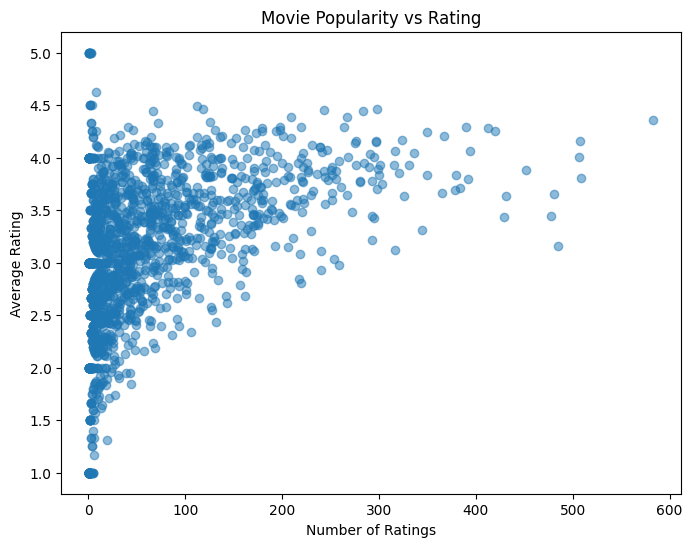

In [49]:
# create a visualization

plt.figure(figsize=(8,6))

plt.scatter(
    movie_stats["num_ratings"],
    movie_stats["avg_rating"],
    alpha = 0.5
)

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("Movie Popularity vs Rating")

plt.show()

## Popularity-Based Recommender

In [50]:
# Generate popularity-based recommendations

recommendations = popular_movies.sort_values(
    ["avg_rating", "num_ratings"],
    ascending=False
)

recommendations.head(10)

,num_ratings,avg_rating
title,,
"Close Shave, A (1995)",112,4.491071
Schindler's List (1993),298,4.466443
"Wrong Trousers, The (1993)",118,4.466102
Casablanca (1942),243,4.456790
"Shawshank Redemption, The (1994)",283,4.445230
Rear Window (1954),209,4.387560
"Usual Suspects, The (1995)",267,4.385768
Star Wars (1977),583,4.358491
12 Angry Men (1957),125,4.344000


## Item-Item Collaborative Filtering

In [51]:
# create the user-movie matrix

user_movie_matrix = movie_ratings.pivot_table(
    index="user_id",
    columns="title",
    values="rating"
)

user_movie_matrix.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN


In [52]:
# check the dimensions of the above table

print(user_movie_matrix.shape)

(943, 1664)


In [53]:
# pick a popular movie

[col for col in user_movie_matrix.columns if "Star Wars" in col]

['Star Wars (1977)']

In [54]:
# find movies similar to star wars -- first display some of star wars ratings and then show similar movies in next cell

star_wars_ratings = user_movie_matrix["Star Wars (1977)"]

star_wars_ratings.head()

user_id
1    5.0
2    5.0
3    NaN
4    5.0
5    4.0
Name: Star Wars (1977), dtype: float64

In [55]:
# warnings are expected -- we have a user-movie matrix with lots of missing values

similar_movies = user_movie_matrix.corrwith(
    star_wars_ratings
)

similar_movies.head()

c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


title
'Til There Was You (1997)    0.872872
1-900 (1994)                -0.645497
101 Dalmatians (1996)        0.211132
12 Angry Men (1957)          0.184289
187 (1997)                   0.027398
dtype: float64

In [56]:
# clean the above results
# what we are seeing is technically correct, but not practically useful; correlation = 1.0 means rating patterns match star wars
# but, some of those may have been rated by only 2 users, 3 users, 4 users, or something like that; next cell is critical

corr_star_wars = pd.DataFrame(
    similar_movies,
    columns=["correlation"]
)

corr_star_wars.dropna(inplace=True)

corr_star_wars.sort_values(
    "correlation",
    ascending=False
).head(20)

,correlation
title,
Star Wars (1977),1.0
Stripes (1981),1.0
Hollow Reed (1996),1.0
Man of the Year (1995),1.0
Cosi (1996),1.0
Commandments (1997),1.0
No Escape (1994),1.0
"Scarlet Letter, The (1926)",1.0
Safe Passage (1994),1.0


In [57]:
movie_stats = movie_ratings.groupby("title").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean")
)

movie_stats.head()

,num_ratings,avg_rating
title,,
'Til There Was You (1997),9,2.333333
1-900 (1994),5,2.600000
101 Dalmatians (1996),109,2.908257
12 Angry Men (1957),125,4.344000
187 (1997),41,3.024390


In [58]:
# join the above stats

corr_star_wars = corr_star_wars.join(
    movie_stats["num_ratings"]
)

corr_star_wars.head()

,correlation,num_ratings
title,,
'Til There Was You (1997),0.872872,9
1-900 (1994),-0.645497,5
101 Dalmatians (1996),0.211132,109
12 Angry Men (1957),0.184289,125
187 (1997),0.027398,41


In [59]:
# after joining, filter

corr_star_wars[
    corr_star_wars["num_ratings"] >= 100
].sort_values(
    "correlation",
    ascending=False
).head(20)

,correlation,num_ratings
title,,
Star Wars (1977),1.000000,583
"Empire Strikes Back, The (1980)",0.747981,367
Return of the Jedi (1983),0.672556,507
Raiders of the Lost Ark (1981),0.536117,420
Austin Powers: International Man of Mystery (1997),0.377433,130
"Sting, The (1973)",0.367538,241
Indiana Jones and the Last Crusade (1989),0.350107,331
Pinocchio (1940),0.347868,101
"Frighteners, The (1996)",0.332729,115


In [60]:
# add one more filter to explore the most popular movies in the dataset

movie_stats.sort_values(
    "num_ratings",
    ascending=False
).head(20)

,num_ratings,avg_rating
title,,
Star Wars (1977),583,4.358491
Contact (1997),509,3.803536
Fargo (1996),508,4.155512
Return of the Jedi (1983),507,4.007890
Liar Liar (1997),485,3.156701
"English Patient, The (1996)",481,3.656965
Scream (1996),478,3.441423
Toy Story (1995),452,3.878319
Air Force One (1997),431,3.631090


In [61]:
# then, try a recommendation for a few other movies

star_wars_ratings = user_movie_matrix["Star Wars (1977)"]

toy_story_ratings = user_movie_matrix["Toy Story (1995)"]

fargo_ratings = user_movie_matrix["Fargo (1996)"]

In [62]:
# reusable recommendation function

def get_recommendations(movie_title, min_ratings=100):

    movie_ratings = user_movie_matrix[movie_title]

    similar_movies = user_movie_matrix.corrwith(movie_ratings)

    corr_df = pd.DataFrame(
        similar_movies,
        columns=["correlation"]
    )

    corr_df.dropna(inplace=True)

    corr_df = corr_df.join(
        movie_stats["num_ratings"]
    )

    recommendations = corr_df[
        corr_df["num_ratings"] >= min_ratings
    ].sort_values(
        "correlation",
        ascending=False
    )

    return recommendations.head(10)

## Recommendation Examples

The following examples demonstrate recommendations generated using item-item collaborative filtering.

### Star Wars

Top recommendations:
- Empire Strikes Back
- Return of the Jedi
- Raiders of the Lost Ark

### Toy Story

Top recommendations:
- The Craft
- Down Periscope
- Miracle on 34th Street

### Fargo

Top recommendations:
- Sling Blade
- Lone Star
- Quiz Show


In [63]:
# test the above function

get_recommendations("Star Wars (1977)")

c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,correlation,num_ratings
title,,
Star Wars (1977),1.000000,583
"Empire Strikes Back, The (1980)",0.747981,367
Return of the Jedi (1983),0.672556,507
Raiders of the Lost Ark (1981),0.536117,420
Austin Powers: International Man of Mystery (1997),0.377433,130
"Sting, The (1973)",0.367538,241
Indiana Jones and the Last Crusade (1989),0.350107,331
Pinocchio (1940),0.347868,101
"Frighteners, The (1996)",0.332729,115


In [64]:
get_recommendations("Toy Story (1995)")

c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,correlation,num_ratings
title,,
Toy Story (1995),1.000000,452
"Craft, The (1996)",0.549100,104
Down Periscope (1996),0.457995,101
Miracle on 34th Street (1994),0.456291,101
G.I. Jane (1997),0.454756,175
Amistad (1997),0.449915,124
Beauty and the Beast (1991),0.442960,202
"Mask, The (1994)",0.432855,129
Cinderella (1950),0.428372,129


In [65]:
get_recommendations("Fargo (1996)")

c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,correlation,num_ratings
title,,
Fargo (1996),1.000000,508
Sling Blade (1996),0.381159,136
Lone Star (1996),0.370915,187
Quiz Show (1994),0.355031,175
Lawrence of Arabia (1962),0.353408,173
True Romance (1993),0.345781,104
Raging Bull (1980),0.344163,116
"People vs. Larry Flynt, The (1996)",0.341784,215
"Magnificent Seven, The (1954)",0.338462,121


## Matrix Factorization with SVD

This section uses matrix factorization to learn latent movie features from the user-movie ratings matrix.

In [66]:
user_movie_filled = user_movie_matrix.fillna(0)

svd = TruncatedSVD(n_components=50, random_state=42)
movie_features = svd.fit_transform(user_movie_filled.T)

movie_features.shape

(1664, 50)

In [67]:
# create a movie similarity matrix

movie_similarity = cosine_similarity(movie_features)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

movie_similarity_df.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
title,,,,,,,,,,,,,,,,,,,,,
'Til There Was You (1997),1.000000,0.031404,0.083296,0.184246,0.450731,0.308084,-0.022396,0.121048,0.059239,0.001427,...,-0.062283,0.041175,0.052773,0.045946,0.207863,0.356007,0.020623,-0.042986,0.315287,0.056247
1-900 (1994),0.031404,1.000000,0.016611,0.215489,0.114303,0.029938,0.073446,0.212234,0.056791,0.197390,...,0.296981,-0.065328,-0.076008,0.192503,0.027031,-0.012815,0.426225,0.018088,0.038257,0.441963
101 Dalmatians (1996),0.083296,0.016611,1.000000,0.253383,0.203132,0.294124,0.486485,0.396245,0.075137,0.213121,...,0.059539,0.141213,0.056126,0.474726,0.348917,0.193512,0.212506,0.575030,0.073216,0.009861
12 Angry Men (1957),0.184246,0.215489,0.253383,1.000000,0.138654,0.299555,0.551620,0.643666,0.347896,0.737844,...,0.156977,0.119459,0.127360,0.574458,0.414127,0.287273,0.245626,0.110188,0.113215,0.128641
187 (1997),0.450731,0.114303,0.203132,0.138654,1.000000,0.360201,0.081695,0.134022,0.211372,0.072393,...,0.040145,0.439515,-0.057055,0.154102,0.206881,0.285900,0.383955,0.107970,0.433602,0.237238


In [68]:
# create an SVD recommendation function

def get_svd_recommendations(movie_title, top_n=10):
    similar_scores = movie_similarity_df[movie_title].sort_values(ascending=False)
    
    recommendations = similar_scores.drop(movie_title).head(top_n)
    
    return recommendations

In [69]:
# testing the above function

get_svd_recommendations("Star Wars (1977)")

title
Return of the Jedi (1983)                    0.979425
Empire Strikes Back, The (1980)              0.863500
Raiders of the Lost Ark (1981)               0.856581
Toy Story (1995)                             0.841176
Star Trek: First Contact (1996)              0.801303
Independence Day (ID4) (1996)                0.798626
Indiana Jones and the Last Crusade (1989)    0.795451
Godfather, The (1972)                        0.786064
Back to the Future (1985)                    0.774871
Fargo (1996)                                 0.771976
Name: Star Wars (1977), dtype: float64

In [70]:
get_svd_recommendations("Toy Story (1995)")

title
Independence Day (ID4) (1996)                   0.846874
Star Wars (1977)                                0.841176
Willy Wonka and the Chocolate Factory (1971)    0.839748
Return of the Jedi (1983)                       0.837793
Rock, The (1996)                                0.818747
Mission: Impossible (1996)                      0.816665
Star Trek: First Contact (1996)                 0.813752
Twelve Monkeys (1995)                           0.798214
Jerry Maguire (1996)                            0.789939
Twister (1996)                                  0.782659
Name: Toy Story (1995), dtype: float64

In [71]:
get_svd_recommendations("Fargo (1996)")

title
Twelve Monkeys (1995)       0.863357
Dead Man Walking (1995)     0.809300
Leaving Las Vegas (1995)    0.806789
Trainspotting (1996)        0.796659
Star Wars (1977)            0.771976
Godfather, The (1972)       0.770863
Birdcage, The (1996)        0.766407
Jerry Maguire (1996)        0.764773
Pulp Fiction (1994)         0.761015
Toy Story (1995)            0.756543
Name: Fargo (1996), dtype: float64

## Model Comparison

The outputs below compare recommendations generated by collaborative filtering and matrix factorization approaches.

The correlation-based recommender identifies movies with similar rating patterns among users who rated both movies. It is easy to interpret but can be sensitive to sparse data.

The SVD-based recommender uses matrix factorization to learn latent movie features. This can capture broader similarity patterns and reduce noise from sparse ratings.

In [72]:
# compare outputs side by side

movie = "Star Wars (1977)"

print("Correlation-based recommendations:")
display(get_recommendations(movie))

print("SVD-based recommendations:")
display(get_svd_recommendations(movie))


Correlation-based recommendations:


c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,correlation,num_ratings
title,,
Star Wars (1977),1.000000,583
"Empire Strikes Back, The (1980)",0.747981,367
Return of the Jedi (1983),0.672556,507
Raiders of the Lost Ark (1981),0.536117,420
Austin Powers: International Man of Mystery (1997),0.377433,130
"Sting, The (1973)",0.367538,241
Indiana Jones and the Last Crusade (1989),0.350107,331
Pinocchio (1940),0.347868,101
"Frighteners, The (1996)",0.332729,115


SVD-based recommendations:


title
Return of the Jedi (1983)                    0.979425
Empire Strikes Back, The (1980)              0.863500
Raiders of the Lost Ark (1981)               0.856581
Toy Story (1995)                             0.841176
Star Trek: First Contact (1996)              0.801303
Independence Day (ID4) (1996)                0.798626
Indiana Jones and the Last Crusade (1989)    0.795451
Godfather, The (1972)                        0.786064
Back to the Future (1985)                    0.774871
Fargo (1996)                                 0.771976
Name: Star Wars (1977), dtype: float64

In [73]:
movie = "Toy Story (1995)"

print("Correlation-based recommendations:")
display(get_recommendations(movie))

print("SVD-based recommendations:")
display(get_svd_recommendations(movie))

Correlation-based recommendations:


c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,correlation,num_ratings
title,,
Toy Story (1995),1.000000,452
"Craft, The (1996)",0.549100,104
Down Periscope (1996),0.457995,101
Miracle on 34th Street (1994),0.456291,101
G.I. Jane (1997),0.454756,175
Amistad (1997),0.449915,124
Beauty and the Beast (1991),0.442960,202
"Mask, The (1994)",0.432855,129
Cinderella (1950),0.428372,129


SVD-based recommendations:


title
Independence Day (ID4) (1996)                   0.846874
Star Wars (1977)                                0.841176
Willy Wonka and the Chocolate Factory (1971)    0.839748
Return of the Jedi (1983)                       0.837793
Rock, The (1996)                                0.818747
Mission: Impossible (1996)                      0.816665
Star Trek: First Contact (1996)                 0.813752
Twelve Monkeys (1995)                           0.798214
Jerry Maguire (1996)                            0.789939
Twister (1996)                                  0.782659
Name: Toy Story (1995), dtype: float64

In [74]:
movie = "Fargo (1996)"

print("Correlation-based recommendations:")
display(get_recommendations(movie))

print("SVD-based recommendations:")
display(get_svd_recommendations(movie))

Correlation-based recommendations:


c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\benja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,correlation,num_ratings
title,,
Fargo (1996),1.000000,508
Sling Blade (1996),0.381159,136
Lone Star (1996),0.370915,187
Quiz Show (1994),0.355031,175
Lawrence of Arabia (1962),0.353408,173
True Romance (1993),0.345781,104
Raging Bull (1980),0.344163,116
"People vs. Larry Flynt, The (1996)",0.341784,215
"Magnificent Seven, The (1954)",0.338462,121


SVD-based recommendations:


title
Twelve Monkeys (1995)       0.863357
Dead Man Walking (1995)     0.809300
Leaving Las Vegas (1995)    0.806789
Trainspotting (1996)        0.796659
Star Wars (1977)            0.771976
Godfather, The (1972)       0.770863
Birdcage, The (1996)        0.766407
Jerry Maguire (1996)        0.764773
Pulp Fiction (1994)         0.761015
Toy Story (1995)            0.756543
Name: Fargo (1996), dtype: float64

## Conclusion

This project built three recommendation approaches: a popularity-based baseline, item-item collaborative filtering, and an SVD-based recommender. Filtering by minimum rating count improved recommendation quality by reducing noisy correlations from sparsely rated movies. The SVD approach captured broader similarity patterns and provides a foundation for more scalable recommendation systems.